In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import time

In [2]:
df = pd.read_csv("../../DataSets/diabetes.csv")

In [3]:
df.rename(columns={"label": 'is_diabetic'}, inplace=True)

In [4]:
df.columns

Index(['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi',
       'pedigree', 'age', 'is_diabetic'],
      dtype='str')

In [5]:
X = df.drop("glucose", axis = 1)
y = df['glucose']

In [6]:
X.columns

Index(['pr', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi', 'pedigree',
       'age', 'is_diabetic'],
      dtype='str')

### Plot Graph

Text(0, 0.5, 'Glucose')

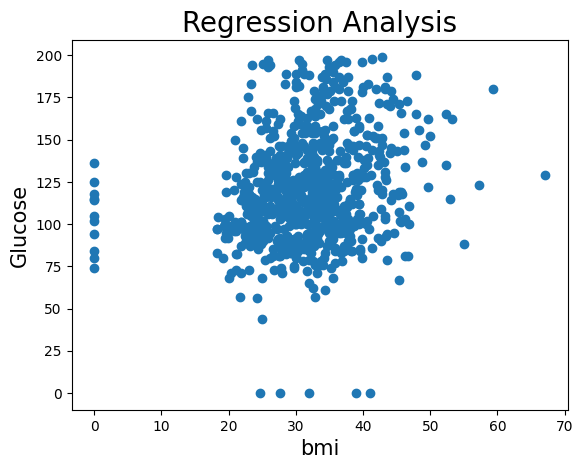

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X["bmi"], y)
plt.title("Regression Analysis", fontsize=20)
plt.xlabel("bmi", fontsize = 15)
plt.ylabel("Glucose", fontsize = 15)

### Linear Regression

In [8]:
from scipy.stats import linregress

In [9]:
slope, intercept, r_value, p_value, std_err = linregress(X["bmi"], y)

In [10]:
y2 = slope*X["bmi"] + intercept

Text(0, 0.5, 'Glucose')

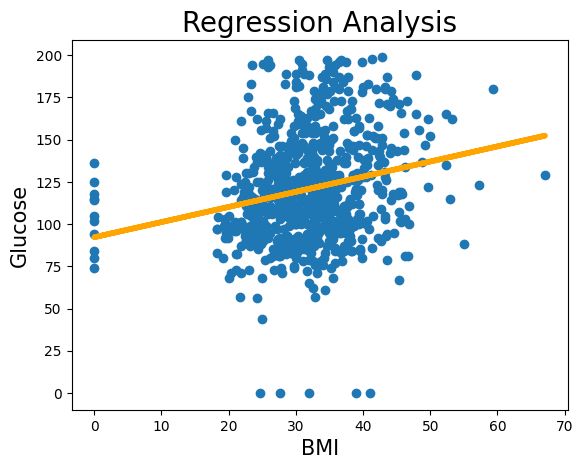

In [11]:
fig = plt.figure()
plt.scatter(X['bmi'], y)
fig = plt.plot(X["bmi"],y2, lw=4, c='orange')
plt.title("Regression Analysis", fontsize = 20)
plt.xlabel("BMI", fontsize = 15)
plt.ylabel("Glucose", fontsize = 15)

### Find the predicted value of unseen data

In [12]:
givenBMI = 50
predGlucose = slope * givenBMI + intercept
predGlucose

np.float64(137.03834751455304)

### Actual Vs Predicted

In [13]:
df_p = pd.DataFrame({"Actual Glucose": y, "Predicted Glucose":y2})
df_p.head()

,Actual Glucose,Predicted Glucose
0,148,122.335599
1,85,116.060036
2,183,113.101556
3,89,117.404800
4,137,130.852435


<Axes: >

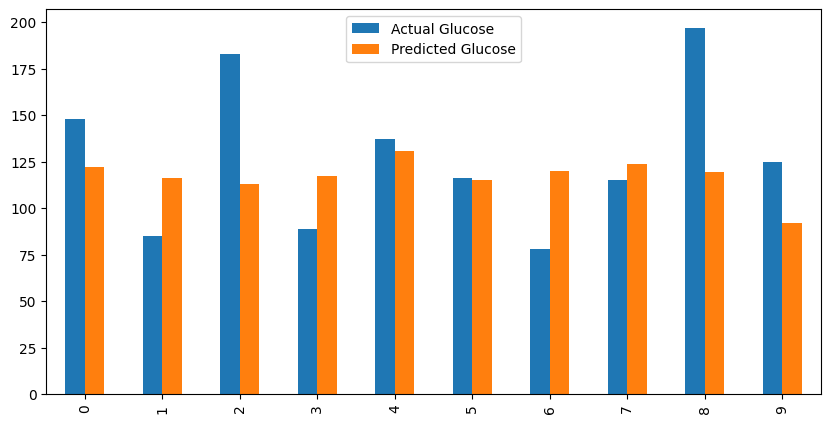

In [14]:
df_p.head(10).plot(kind="bar", figsize=(10, 5))

In [15]:
df_a_p = pd.DataFrame({**df, "Predicted Glucose": y2})
df_a_p.head()

,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,is_diabetic,Predicted Glucose
0,6,148,72,35,0,33.6,0.627,50,1,122.335599
1,1,85,66,29,0,26.6,0.351,31,0,116.060036
2,8,183,64,0,0,23.3,0.672,32,1,113.101556
3,1,89,66,23,94,28.1,0.167,21,0,117.404800
4,0,137,40,35,168,43.1,2.288,33,1,130.852435


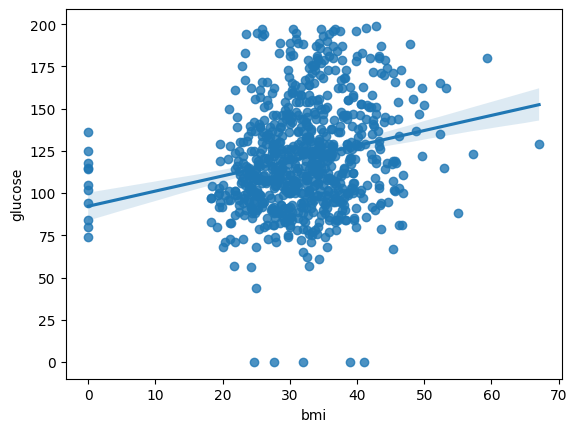

In [16]:
p = sns.regplot(data=df, x=df.bmi, y=df.glucose)

#### Add regression equation to plot

<Axes: xlabel='bmi', ylabel='glucose'>

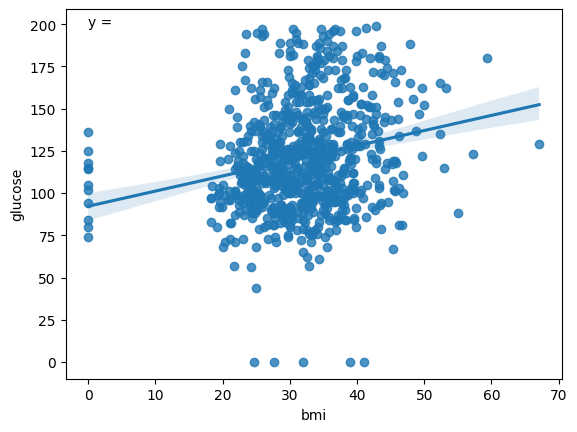

In [17]:
plt.text(min(df.bmi), max(df.glucose), 'y = ')
sns.regplot(data=df, x=df.bmi, y = df.glucose)